# Sensitivity Analysis

Sensitivity analysis shows how valuation changes when key assumptions change. It turns a single valuation estimate into a range of possible outcomes and helps identify which assumptions matter most.

Abbreviations used in this notebook:

- **DCF**: Discounted Cash Flow, a valuation method based on present values of future cash flows.
- **FCF**: Free Cash Flow, cash generated after capital expenditures.
- **WACC**: Weighted Average Cost of Capital, the discount rate for free cash flows to the firm.
- **TV**: Terminal Value, the estimated value after the explicit forecast period.
- **EV**: Enterprise Value, the value of the operating business.
- **CHF**: Swiss franc, the currency used in the examples.

## 1. Intuition

A valuation model can look precise, but the result depends on assumptions. Sensitivity analysis asks: if an assumption changes, how much does the valuation change?

There are three common approaches:

- **One-way sensitivity**: change one input while holding all others constant.
- **Two-way sensitivity**: change two inputs at the same time, often shown as a table or heatmap.
- **Scenario analysis**: combine several assumptions into coherent downside, base, and upside cases.

The goal is not to predict the future perfectly. The goal is to understand the range of plausible values and the assumptions that drive that range.

## 2. Mathematics

**DCF enterprise value:**

$$
EV = \sum_{t=1}^{N} \frac{FCF_t}{(1 + WACC)^t} + \frac{TV}{(1 + WACC)^N}
$$

Where:

- $FCF_t$ = free cash flow in period $t$
- $WACC$ = weighted average cost of capital
- $TV$ = terminal value
- $EV$ = enterprise value, the value of the operating business
- $t$ = time period index

**Terminal value using Gordon Growth:**

$$
TV = \frac{FCF_N \times (1 + g_{terminal})}{WACC - g_{terminal}}
$$

Where:

- $FCF_N$ = free cash flow in the final explicit forecast year
- $WACC$ = weighted average cost of capital
- $TV$ = terminal value
- $g_{terminal}$ = perpetual terminal growth rate

**Equity value:**

$$
\text{Equity Value} = EV - \text{Net Debt}
$$

Where:

- $EV$ = enterprise value, the value of the operating business
- $\text{Equity Value}$ = value attributable to shareholders
- $\text{Net Debt}$ = debt minus cash and cash equivalents

**Value per share:**

$$
\text{Value per Share} = \frac{\text{Equity Value}}{\text{Shares Outstanding}}
$$

Where:

- $\text{Equity Value}$ = value attributable to shareholders
- $\text{Value per Share}$ = intrinsic equity value per share
- $\text{Shares Outstanding}$ = number of shares issued and outstanding

**Sensitivity to an input $x$ can be summarized as:**

$$
\Delta Value = Value(x_{new}) - Value(x_{base})
$$

Where:

- $\Delta Value$ = absolute change in valuation
- $Value(x_{new})$ = valuation after changing assumption $x$
- $Value(x_{base})$ = valuation using the base-case assumption for $x$
- $x$ = input assumption being tested

**Percentage change:**

$$
\%\Delta Value = \frac{Value(x_{new})}{Value(x_{base})} - 1
$$

Where:

- $\Delta Value$ = absolute change in valuation
- $\%\Delta Value$ = percentage change in valuation
- $Value(x_{new})$ = valuation after changing assumption $x$
- $Value(x_{base})$ = valuation using the base-case assumption for $x$
- $x$ = input assumption being tested

## 3. Implementation

We will use a compact DCF model and test how value per share changes across WACC, forecast growth, terminal growth, margin, and net debt assumptions.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")


def dcf_value_per_share(
    revenue,
    fcf_margin,
    forecast_growth,
    wacc,
    terminal_growth,
    years,
    net_debt,
    shares_outstanding,
):
    if wacc <= terminal_growth:
        raise ValueError("WACC must be greater than terminal growth.")

    projected_revenue = np.array([revenue * (1 + forecast_growth) ** year for year in range(1, years + 1)])
    projected_fcf = projected_revenue * fcf_margin
    discount_factors = np.array([(1 + wacc) ** year for year in range(1, years + 1)])
    pv_fcfs = projected_fcf / discount_factors

    terminal_value = projected_fcf[-1] * (1 + terminal_growth) / (wacc - terminal_growth)
    pv_terminal_value = terminal_value / ((1 + wacc) ** years)
    enterprise_value = pv_fcfs.sum() + pv_terminal_value
    equity_value = enterprise_value - net_debt

    return equity_value / shares_outstanding


base_assumptions = {
    "revenue": 102_000,
    "fcf_margin": 0.135,
    "forecast_growth": 0.035,
    "wacc": 0.060,
    "terminal_growth": 0.020,
    "years": 5,
    "net_debt": 35_000,
    "shares_outstanding": 2_650,
}

base_value = dcf_value_per_share(**base_assumptions)
print(f"Base value per share: CHF {base_value:,.2f}")

Base value per share: CHF 128.59


One-way sensitivity changes a single assumption at a time. This is the cleanest way to isolate the impact of one driver.

In [22]:
def one_way_sensitivity(input_name, values):
    rows = []
    for value in values:
        assumptions = base_assumptions.copy()
        assumptions[input_name] = value
        case_value = dcf_value_per_share(**assumptions)
        rows.append({
            "input": input_name,
            "assumption": value,
            "value_per_share": case_value,
            "change_vs_base": case_value / base_value - 1,
        })
    return pd.DataFrame(rows)

one_way = pd.concat([
    one_way_sensitivity("wacc", np.linspace(0.045, 0.080, 8)),
    one_way_sensitivity("forecast_growth", np.linspace(0.010, 0.060, 8)),
    one_way_sensitivity("terminal_growth", np.linspace(0.010, 0.030, 8)),
    one_way_sensitivity("fcf_margin", np.linspace(0.105, 0.165, 8)),
], ignore_index=True)

one_way.head(10).round(4)

,input,assumption,value_per_share,change_vs_base
0,wacc,0.0450,214.0917,0.6649
1,wacc,0.0500,176.0888,0.3694
2,wacc,0.0550,148.9459,0.1583
3,wacc,0.0600,128.5903,0.0000
4,wacc,0.0650,112.7596,-0.1231
5,wacc,0.0700,100.0963,-0.2216
6,wacc,0.0750,89.7365,-0.3022
7,wacc,0.0800,81.1044,-0.3693
8,forecast_growth,0.0100,113.3855,-0.1182
9,forecast_growth,0.0171,117.5845,-0.0856


## 4. Visualization

Sensitivity charts make assumptions visible. They help move the discussion from "the model says" to "the model depends on these drivers."

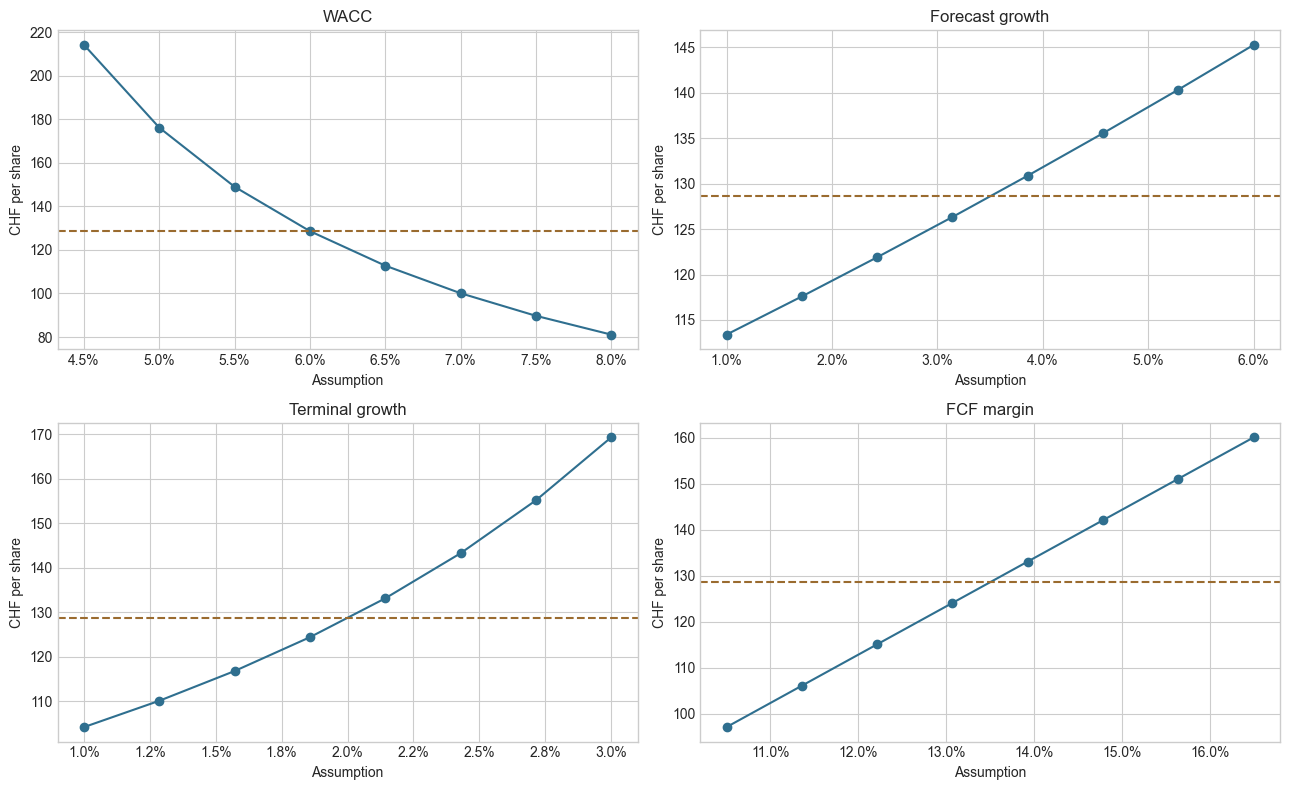

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

labels = {
    "wacc": "WACC",
    "forecast_growth": "Forecast growth",
    "terminal_growth": "Terminal growth",
    "fcf_margin": "FCF margin",
}

for ax, input_name in zip(axes, labels):
    data = one_way[one_way["input"] == input_name]
    ax.plot(data["assumption"], data["value_per_share"], marker="o", color="#2f6f8f")
    ax.axhline(base_value, color="#9a6b2f", linestyle="--", label="Base value")
    ax.set_title(labels[input_name])
    ax.set_xlabel("Assumption")
    ax.set_ylabel("CHF per share")
    ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.1%}")

plt.tight_layout()
plt.show()

In [24]:
wacc_values = np.linspace(0.045, 0.080, 8)
terminal_growth_values = np.linspace(0.010, 0.030, 8)

two_way = pd.DataFrame(index=wacc_values, columns=terminal_growth_values, dtype=float)
for wacc in wacc_values:
    for terminal_growth in terminal_growth_values:
        assumptions = base_assumptions.copy()
        assumptions["wacc"] = wacc
        assumptions["terminal_growth"] = terminal_growth
        two_way.loc[wacc, terminal_growth] = dcf_value_per_share(**assumptions)

two_way.round(2)

,0.010000,0.012857,0.015714,0.018571,0.021429,0.024286,0.027143,0.030000
0.045,154.95,168.09,183.80,202.90,226.64,256.92,296.89,352.10
0.050,133.78,143.54,154.93,168.40,184.55,204.30,228.98,260.71
0.055,117.32,124.82,133.42,143.36,155.00,168.81,185.44,205.88
0.060,104.15,110.07,116.76,124.38,133.12,143.26,155.16,169.33
0.065,93.38,98.16,103.49,109.48,116.25,123.98,132.87,143.22
0.070,84.40,88.33,92.66,97.48,102.87,108.92,115.79,123.64
0.075,76.81,80.08,83.66,87.61,91.98,96.84,102.28,108.41
0.080,70.30,73.06,76.06,79.35,82.95,86.92,91.32,96.23


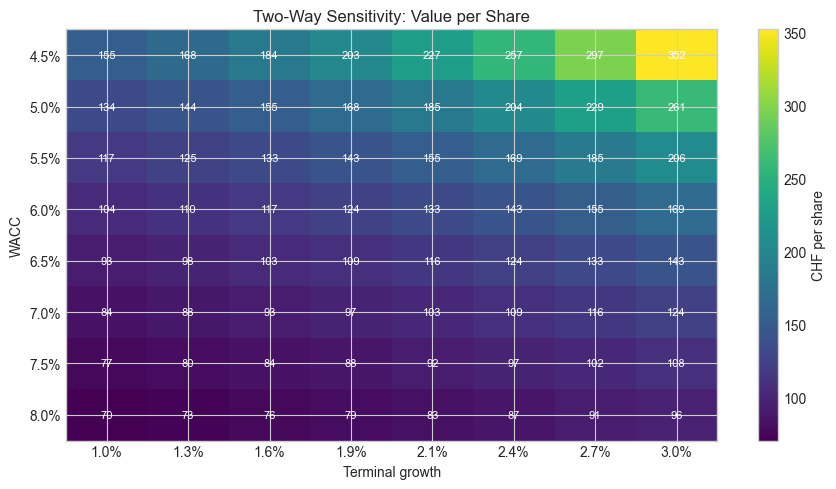

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
image = ax.imshow(two_way.values, aspect="auto", cmap="viridis")

ax.set_xticks(range(len(terminal_growth_values)))
ax.set_xticklabels([f"{g:.1%}" for g in terminal_growth_values])
ax.set_yticks(range(len(wacc_values)))
ax.set_yticklabels([f"{w:.1%}" for w in wacc_values])
ax.set_xlabel("Terminal growth")
ax.set_ylabel("WACC")
ax.set_title("Two-Way Sensitivity: Value per Share")

for row in range(two_way.shape[0]):
    for col in range(two_way.shape[1]):
        ax.text(col, row, f"{two_way.values[row, col]:.0f}", ha="center", va="center", color="white", fontsize=8)

fig.colorbar(image, ax=ax, label="CHF per share")
plt.tight_layout()
plt.show()

A tornado chart ranks assumptions by impact. It is useful when you want to know which inputs deserve the most research effort.

In [26]:
tornado_inputs = {
    "WACC": ("wacc", base_assumptions["wacc"] - 0.005, base_assumptions["wacc"] + 0.005),
    "Forecast growth": ("forecast_growth", base_assumptions["forecast_growth"] - 0.010, base_assumptions["forecast_growth"] + 0.010),
    "Terminal growth": ("terminal_growth", base_assumptions["terminal_growth"] - 0.005, base_assumptions["terminal_growth"] + 0.005),
    "FCF margin": ("fcf_margin", base_assumptions["fcf_margin"] - 0.010, base_assumptions["fcf_margin"] + 0.010),
    "Net debt": ("net_debt", base_assumptions["net_debt"] - 5_000, base_assumptions["net_debt"] + 5_000),
}

rows = []
for label, (input_name, low, high) in tornado_inputs.items():
    low_case = base_assumptions.copy()
    high_case = base_assumptions.copy()
    low_case[input_name] = low
    high_case[input_name] = high

    low_value = dcf_value_per_share(**low_case)
    high_value = dcf_value_per_share(**high_case)
    rows.append({
        "driver": label,
        "low_case_value": low_value,
        "high_case_value": high_value,
        "absolute_impact": max(abs(low_value - base_value), abs(high_value - base_value)),
    })

tornado = pd.DataFrame(rows).sort_values("absolute_impact", ascending=True)
tornado.round(2)

,driver,low_case_value,high_case_value,absolute_impact
4,Net debt,130.48,126.70,1.89
1,Forecast growth,122.34,135.08,6.49
3,FCF margin,118.09,139.09,10.50
2,Terminal growth,115.01,146.05,17.46
0,WACC,148.95,112.76,20.36


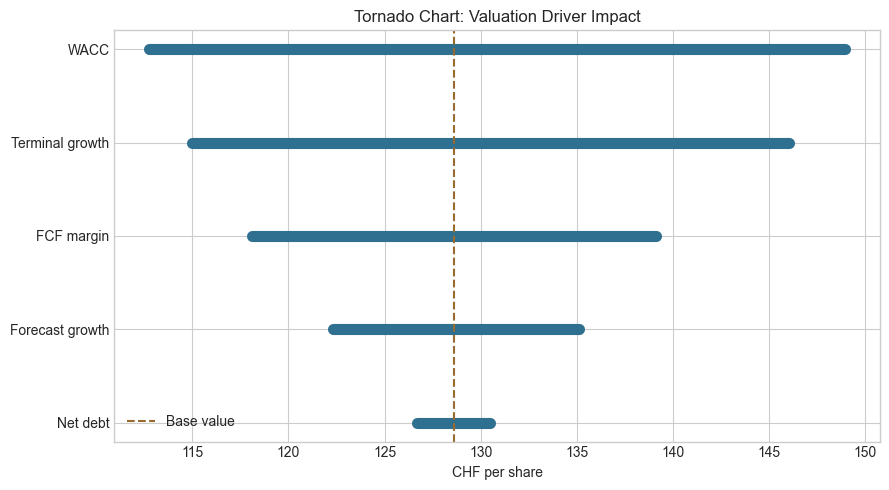

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))

for _, row in tornado.iterrows():
    ax.plot([row["low_case_value"], row["high_case_value"]], [row["driver"], row["driver"]], linewidth=8, color="#2f6f8f")

ax.axvline(base_value, color="#9a6b2f", linestyle="--", label="Base value")
ax.set_title("Tornado Chart: Valuation Driver Impact")
ax.set_xlabel("CHF per share")
ax.legend()

plt.tight_layout()
plt.show()

## 5. Application

Sensitivity analysis is used in equity research, investment banking, and investment decision-making. It helps answer practical questions:

- What valuation range is reasonable?
- Which assumptions create the largest valuation movement?
- What must be true for the current market price to be justified?
- Which inputs deserve more research before making a decision?
- Is the investment thesis robust, or does it depend on a narrow set of optimistic assumptions?

For a stable company, WACC, terminal growth, and FCF margin usually dominate the valuation conversation. For faster-growing companies, forecast growth and reinvestment assumptions can matter even more.

In [28]:
scenario_cases = pd.DataFrame({
    "scenario": ["Downside", "Base", "Upside"],
    "revenue": [100_000, 102_000, 104_000],
    "fcf_margin": [0.120, 0.135, 0.150],
    "forecast_growth": [0.020, 0.035, 0.050],
    "wacc": [0.070, 0.060, 0.052],
    "terminal_growth": [0.015, 0.020, 0.025],
    "years": [5, 5, 5],
    "net_debt": [38_000, 35_000, 32_000],
    "shares_outstanding": [2_650, 2_650, 2_650],
})

scenario_cases["value_per_share"] = scenario_cases.apply(
    lambda row: dcf_value_per_share(
        revenue=row["revenue"],
        fcf_margin=row["fcf_margin"],
        forecast_growth=row["forecast_growth"],
        wacc=row["wacc"],
        terminal_growth=row["terminal_growth"],
        years=int(row["years"]),
        net_debt=row["net_debt"],
        shares_outstanding=row["shares_outstanding"],
    ),
    axis=1,
)

scenario_cases[["scenario", "value_per_share"]].round(2)

,scenario,value_per_share
0,Downside,71.10
1,Base,128.59
2,Upside,238.55


In [29]:
print(f"Base value: CHF {base_value:,.2f}")
print(f"Downside scenario: CHF {scenario_cases.loc[0, 'value_per_share']:,.2f}")
print(f"Upside scenario: CHF {scenario_cases.loc[2, 'value_per_share']:,.2f}")
print(f"Scenario range width: CHF {scenario_cases['value_per_share'].max() - scenario_cases['value_per_share'].min():,.2f}")

Base value: CHF 128.59
Downside scenario: CHF 71.10
Upside scenario: CHF 238.55
Scenario range width: CHF 167.45


## 6. Reflection

- A valuation range is more honest than a single exact-looking number.
- One-way sensitivity isolates individual drivers.
- Two-way sensitivity shows how important assumptions interact.
- Scenario analysis combines assumptions into coherent stories.
- Tornado charts help prioritize which inputs need deeper research.
- Sensitivity analysis does not remove uncertainty; it makes uncertainty visible.

Questions to answer after running the notebook:

1. Which assumption has the largest impact on value per share?
2. Why are WACC and terminal growth often analyzed together?
3. Which scenario feels most realistic, and what evidence would support it?
4. How would you use this analysis before making an investment recommendation?